# Práctica: Regresión Polinomial (Dataset Diabetes)

## Paso 1: Importación de dependencias

In [1]:
# 1. Librerías de manipulación y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Librerías para importar el dataset y separar datos
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# 3. Librerías de Machine Learning (Regresión Polinomial)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 4. Métricas de evaluación para Regresión
from sklearn.metrics import mean_squared_error, r2_score

## Paso 2: Carga del dataset
Utilizamos la herramienta integrada de Scikit-Learn para importar el dataset directamente a un DataFrame de Pandas.

In [2]:
# Cargamos el dataset de diabetes
diabetes = load_diabetes(as_frame=True)

# Extraemos el DataFrame
df = diabetes.frame

In [3]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
# Vemos las primeras filas para entender la estructura
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Paso 3: Exploración Inicial (EDA)
Vamos a visualizar cómo se relaciona el Índice de Masa Corporal con la progresión de la enfermedad.

In [5]:
df.shape

(442, 11)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

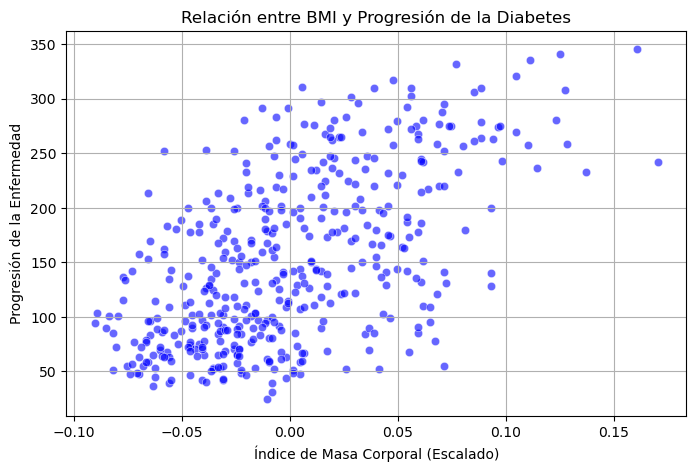

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='target', alpha=0.6, color='blue')
plt.title('Relación entre BMI y Progresión de la Diabetes')
plt.xlabel('Índice de Masa Corporal (Escalado)')
plt.ylabel('Progresión de la Enfermedad')
plt.grid(True)
plt.show()

# Observarás una "nube" de puntos (ruido) que tiende a subir, 
# donde una curva podría ajustarse mejor a los valores extremos que una línea recta.

## Paso 5: Separación de Variables y Train/Test Split
Aislamos nuestra variable X y nuestra y, y separamos los datos para entrenar (80%) y probar (20%).

In [8]:
# Separar X e y (Usamos doble corchete en 'bmi' para que sea un DataFrame/Matriz 2D)
X = df[['bmi']]
y = df['target']

# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Paso 6: Transformación Polinomial
Aquí es donde aplicamos el "truco". Convertimos nuestra única columna bmi en varias columnas elevadas a distintas potencias (grado 3 en este caso: $x, x^2, x^3$).

In [9]:
# Definimos el grado del polinomio 
grado = 3
poly = PolynomialFeatures(degree=grado)

# Transformamos X_train y X_test
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test) 
# NOTA: En el test usamos solo .transform(), no .fit_transform() para evitar fugas de datos.

## Paso 7: Entrenamiento del Modelo
Entrenamos una Regresión Lineal clásica, pero pasándole nuestros datos que ya tienen forma de polinomio.

In [10]:
# Instanciamos y entrenamos el modelo
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly_train, y_train)

# Hacemos las predicciones usando los datos de prueba
y_pred = modelo_poly.predict(X_poly_test)

## Paso 8: Visualización del Resultado (La Curva vs El Ruido)
Vamos a graficar los puntos reales del conjunto de prueba y la curva que trazó nuestro algoritmo para ver cómo lidia con el ruido.

C:\Users\arroy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


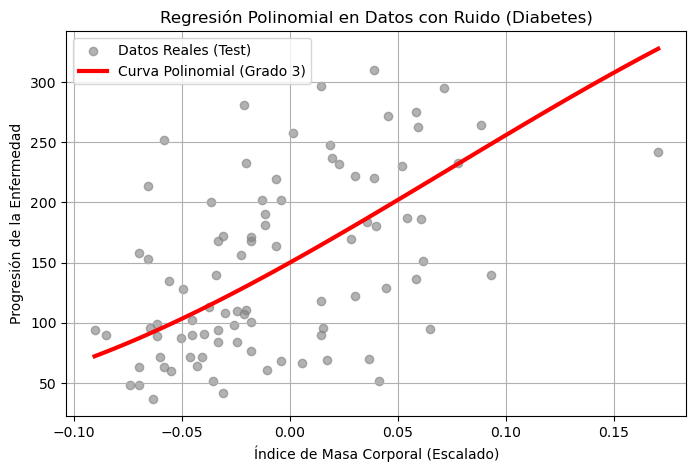

In [11]:
plt.figure(figsize=(8, 5))
# Graficamos los datos reales de prueba
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Datos Reales (Test)')

# Para que la curva se dibuje sin cortes raros, creamos puntos ordenados
X_ordenado = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_ordenado_poly = poly.transform(X_ordenado)
y_curva_pred = modelo_poly.predict(X_ordenado_poly)

# Dibujamos la curva de predicci  ón
plt.plot(X_ordenado, y_curva_pred, color='red', linewidth=3, label=f'Curva Polinomial (Grado {grado})')

plt.title('Regresión Polinomial en Datos con Ruido (Diabetes)')
plt.xlabel('Índice de Masa Corporal (Escalado)')
plt.ylabel('Progresión de la Enfermedad')
plt.legend()
plt.grid(True)
plt.show()

## Paso 9: Evaluación del Modelo
Evaluamos qué tanto se equivoca nuestro modelo en promedio, y qué porcentaje del problema logró entender.

In [12]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Evaluación del Modelo en Datos de Prueba ---")
print(f"R2 Score: {r2:.4f}")
print(f"Error Cuadrático Medio (RMSE): {rmse:.2f}")

--- Evaluación del Modelo en Datos de Prueba ---
R2 Score: 0.2329
Error Cuadrático Medio (RMSE): 63.75


## Conclusión General

"La Regresión Polinomial es una herramienta fundamental en el Machine Learning porque soluciona la mayor limitación de los modelos tradicionales: la rigidez. En el mundo real, los fenómenos biológicos, económicos o físicos rara vez se comportan como una línea recta perfecta; suelen tener curvas, aceleraciones o límites.

Utilizamos este algoritmo porque nos permite adaptar un modelo lineal estándar a datos complejos y ruidosos mediante un ingenioso ajuste matemático (elevar las variables a distintos grados). Su gran importancia radica en que le da a nuestro modelo la flexibilidad exacta para descubrir la verdadera tendencia oculta en los datos, permitiéndonos realizar predicciones mucho más precisas, naturales y apegadas a la realidad, sin caer en el error de memorizar el ruido (sobreajuste)."